# ✈️ Logistic Regression – Airline Customer Satisfaction Prediction

**Project:** Binomial Logistic Regression Classification  
**Dataset:** Invistico Airline Passenger Survey (129,880 records, 22 columns)  
**Goal:** Predict whether a passenger is `satisfied` or `dissatisfied` using flight and service features, then translate model outputs into actionable business recommendations.

---

## 📋 Project Outline
1. Import Libraries
2. Load the Dataset (Google Colab)
3. Inspect the Data & Target Variable
4. Handle Missing Values
5. Exploratory Data Analysis (EDA)
6. Feature Engineering & Encoding
7. Train / Test Split + Feature Scaling
8. Build Logistic Regression Model
9. Evaluate: Confusion Matrix, Precision & Recall
10. Interpret Coefficients – Key Satisfaction Drivers
11. Business Recommendations
12. Final Summary

---
## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---
## 📂 Step 2: Load the Dataset

> **Google Colab:** Upload `Invistico_Airline.csv` using the Files panel on the left sidebar, then run the cell below.

In [2]:
# ── Uncomment if you want to use the Colab file uploader ──
# from google.colab import files
# uploaded = files.upload()

# ── Load the dataset ──
df = pd.read_csv('Invistico_Airline.csv')

print(f'✅ Dataset loaded successfully!')
print(f'   Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

✅ Dataset loaded successfully!
   Rows: 129,880  |  Columns: 22


---
## 🔍 Step 3: Inspect the Dataset & Target Variable

In [3]:
df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

In [5]:
df.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [6]:
# ── Target Variable: satisfaction ──
print('🎯 Target Variable Distribution:')
print(df['satisfaction'].value_counts())
print()
print('Class Balance (%)')
print(df['satisfaction'].value_counts(normalize=True).mul(100).round(2))

🎯 Target Variable Distribution:
satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

Class Balance (%)
satisfaction
satisfied       54.73
dissatisfied    45.27
Name: proportion, dtype: float64


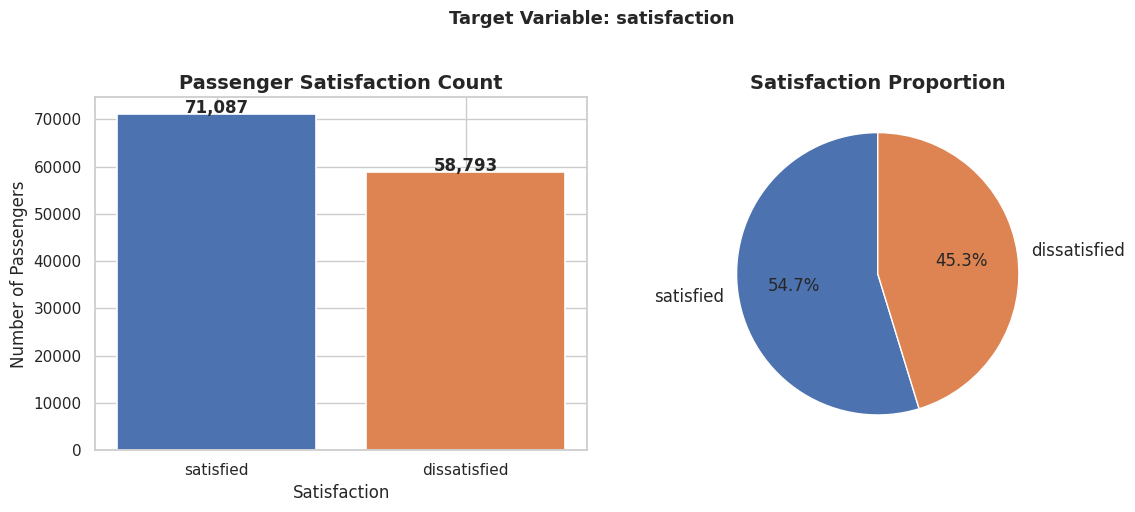


📌 The dataset is slightly imbalanced: 54.7% satisfied vs 45.3% dissatisfied.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['satisfaction'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Passenger Satisfaction Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Satisfaction')
axes[0].set_ylabel('Number of Passengers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Satisfaction Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: satisfaction', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 The dataset is slightly imbalanced: 54.7% satisfied vs 45.3% dissatisfied.')

---
## 🧹 Step 4: Handle Missing Values

The `Arrival Delay in Minutes` column contains **393 missing values** (~0.3% of data). We fill them with the column **median** to avoid distorting the distribution.

In [8]:
# Check all columns for missing values
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill Arrival Delay with median (robust to outliers)
median_delay = df['Arrival Delay in Minutes'].median()
df = df.assign(**{'Arrival Delay in Minutes': df['Arrival Delay in Minutes'].fillna(median_delay)})

print(f'\n✅ Filled 393 missing values in "Arrival Delay in Minutes" with median: {median_delay} minutes')
print(f'   Remaining missing values: {df.isnull().sum().sum()}')

Missing values per column:
Arrival Delay in Minutes    393
dtype: int64

✅ Filled 393 missing values in "Arrival Delay in Minutes" with median: 0.0 minutes
   Remaining missing values: 0


---
## 📊 Step 5: Exploratory Data Analysis (EDA)

Before modelling, we explore how satisfaction varies across key passenger segments and service ratings.

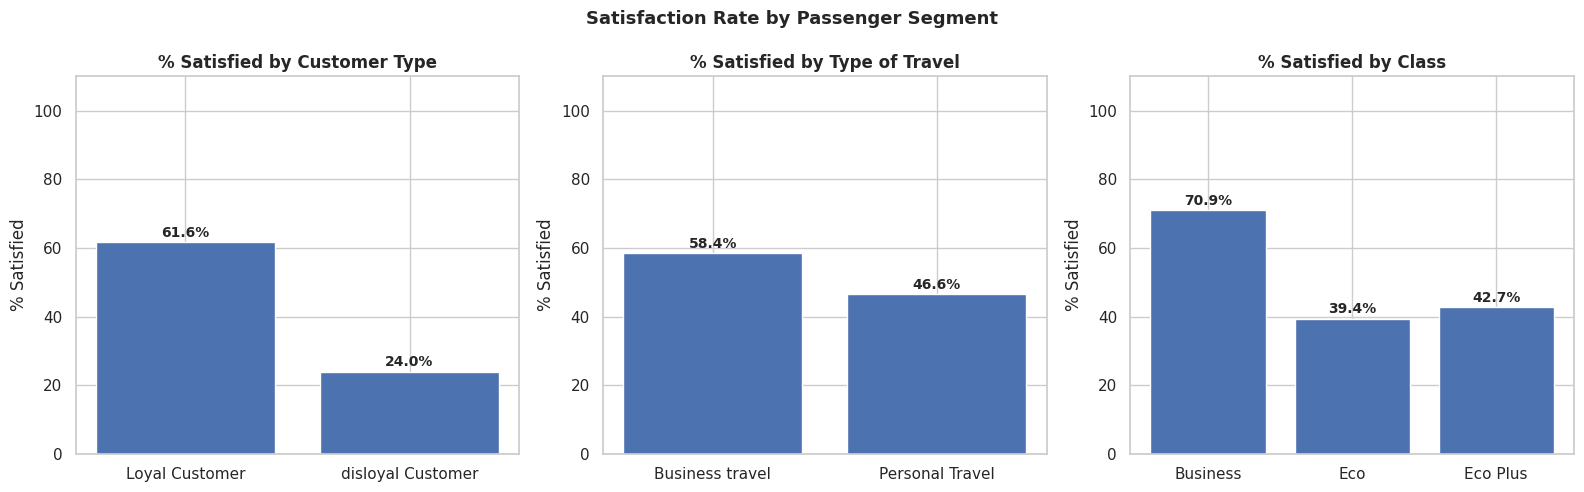


📌 Observations:
   • Loyal customers are far more likely to be satisfied than disloyal ones.
   • Business travelers show higher satisfaction than personal travelers.
   • Business class passengers are most satisfied; Eco Plus least satisfied.


In [9]:
# Satisfaction rate by categorical segments
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['Customer Type', 'Type of Travel', 'Class']):
    sat_rate = (
        df.groupby(col)['satisfaction']
        .apply(lambda x: (x == 'satisfied').mean() * 100)
        .reset_index()
    )
    sat_rate.columns = [col, 'pct_satisfied']
    bars = ax.bar(sat_rate[col], sat_rate['pct_satisfied'],
                  color='#4C72B0', edgecolor='white', linewidth=1)
    ax.set_title(f'% Satisfied by {col}', fontweight='bold', fontsize=12)
    ax.set_ylabel('% Satisfied')
    ax.set_ylim(0, 110)
    for bar, val in zip(bars, sat_rate['pct_satisfied']):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Satisfaction Rate by Passenger Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Observations:')
print('   • Loyal customers are far more likely to be satisfied than disloyal ones.')
print('   • Business travelers show higher satisfaction than personal travelers.')
print('   • Business class passengers are most satisfied; Eco Plus least satisfied.')

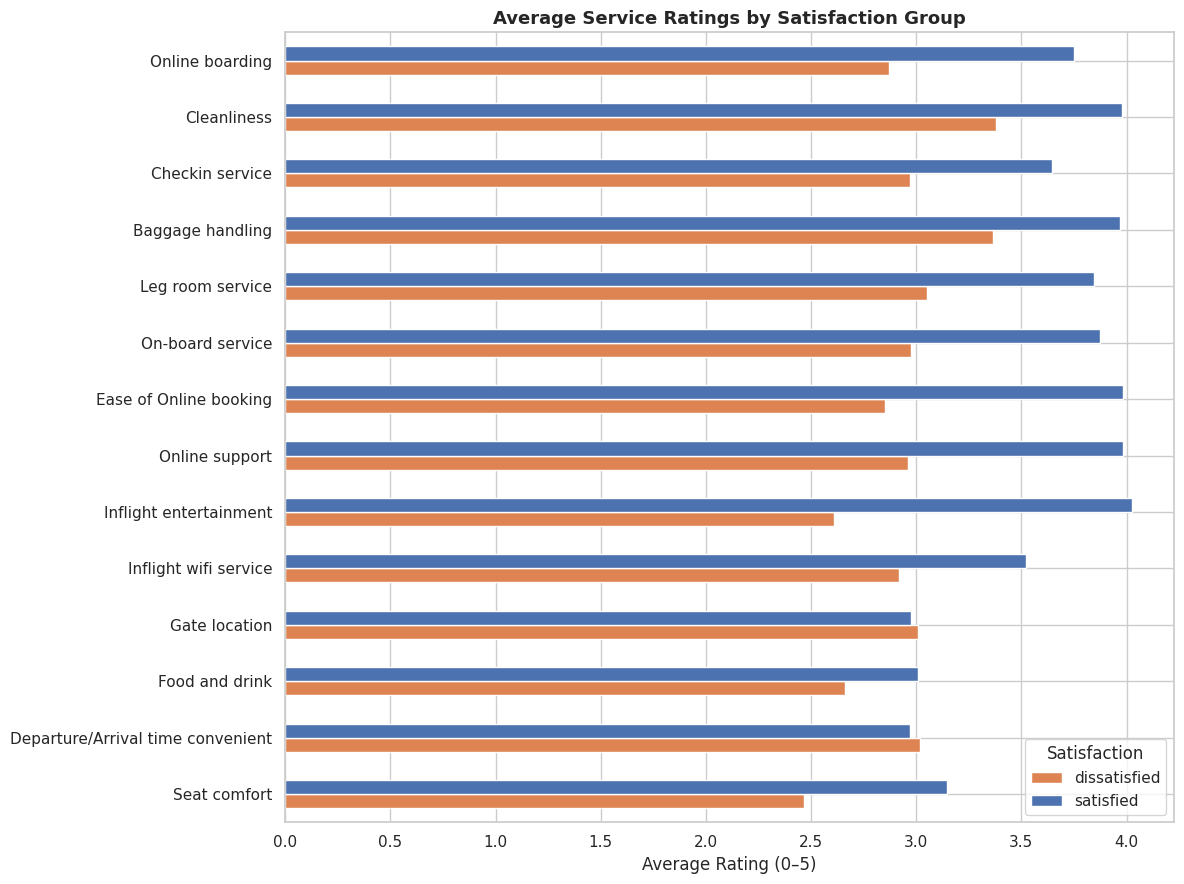


📌 Services with the LARGEST gap between groups drive satisfaction most.
   Inflight entertainment, Seat comfort, and On-board service show notable gaps.


In [10]:
# Average service ratings by satisfaction group
service_cols = [
    'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink',
    'Gate location', 'Inflight wifi service', 'Inflight entertainment',
    'Online support', 'Ease of Online booking', 'On-board service',
    'Leg room service', 'Baggage handling', 'Checkin service',
    'Cleanliness', 'Online boarding'
]

rating_by_sat = df.groupby('satisfaction')[service_cols].mean().T
rating_by_sat.plot(kind='barh', figsize=(12, 9), color=['#DD8452', '#4C72B0'], edgecolor='white')
plt.title('Average Service Ratings by Satisfaction Group', fontsize=13, fontweight='bold')
plt.xlabel('Average Rating (0–5)')
plt.legend(title='Satisfaction', loc='lower right')
plt.tight_layout()
plt.savefig('eda_service_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Services with the LARGEST gap between groups drive satisfaction most.')
print('   Inflight entertainment, Seat comfort, and On-board service show notable gaps.')

---
## ⚙️ Step 6: Feature Engineering & Encoding

**Why encoding?** Logistic Regression requires all inputs to be **numeric**. We must convert categorical text columns:

| Column | Type | Encoding Method | Reason |
|---|---|---|---|
| `satisfaction` | Binary target | `.map()` | Simple 1/0 mapping |
| `Customer Type` | Binary (2 values) | `LabelEncoder` | 0/1 integer |
| `Type of Travel` | Binary (2 values) | `LabelEncoder` | 0/1 integer |
| `Class` | 3 categories | `pd.get_dummies` (drop first) | Avoids dummy trap |

In [11]:
df_model = df.copy()

# 1. Encode TARGET
df_model = df_model.assign(
    satisfaction_enc=df_model['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0})
)
print('✅ Target encoded  →  satisfied=1  |  dissatisfied=0')
print(df_model['satisfaction_enc'].value_counts())

# 2. Label Encode binary categoricals
le = LabelEncoder()
df_model = df_model.assign(
    CustomerType_enc=le.fit_transform(df_model['Customer Type']),
    TravelType_enc=le.fit_transform(df_model['Type of Travel'])
)
print('\n✅ Label encoded: Customer Type → 0=disloyal, 1=loyal')
print('✅ Label encoded: Type of Travel → check le.classes_ for mapping')

# 3. One-Hot Encode Class (3 categories → 2 dummy columns, drop_first avoids multicollinearity)
class_dummies = pd.get_dummies(df_model['Class'], prefix='Class', drop_first=True)
df_model = pd.concat([df_model, class_dummies], axis=1)
print('\n✅ One-hot encoded: Class → Class_Eco | Class_Eco Plus (Business = reference)')
print('   New columns:', [c for c in df_model.columns if 'Class_' in c])

print(f'\n📐 df_model shape: {df_model.shape}')

✅ Target encoded  →  satisfied=1  |  dissatisfied=0
satisfaction_enc
1    71087
0    58793
Name: count, dtype: int64

✅ Label encoded: Customer Type → 0=disloyal, 1=loyal
✅ Label encoded: Type of Travel → check le.classes_ for mapping

✅ One-hot encoded: Class → Class_Eco | Class_Eco Plus (Business = reference)
   New columns: ['Class_Eco', 'Class_Eco Plus']

📐 df_model shape: (129880, 27)


---
## ✂️ Step 7: Train / Test Split & Feature Scaling

**Split:** 80% train / 20% test with `stratify=y` — ensures both splits maintain the original class ratio (54.7% / 45.3%).

**Scaling:** We apply `StandardScaler` (zero mean, unit variance) because:
- `Flight Distance` ranges in the thousands; service ratings only go 0–5
- Without scaling, large-magnitude features dominate the gradient
- Scaled coefficients are directly comparable in magnitude

In [12]:
# Define feature set and target
feature_cols = [
    'Age', 'Flight Distance',
    'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink',
    'Gate location', 'Inflight wifi service', 'Inflight entertainment',
    'Online support', 'Ease of Online booking', 'On-board service',
    'Leg room service', 'Baggage handling', 'Checkin service',
    'Cleanliness', 'Online boarding',
    'Departure Delay in Minutes', 'Arrival Delay in Minutes',
    'CustomerType_enc', 'TravelType_enc', 'Class_Eco', 'Class_Eco Plus'
]

X = df_model[feature_cols]
y = df_model['satisfaction_enc']

# Train / Test Split – 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train set: {X_train.shape[0]:,} rows')
print(f'✅ Test set:  {X_test.shape[0]:,} rows')
print(f'\nTrain class balance (%):')
print(y_train.value_counts(normalize=True).mul(100).round(2))
print(f'\nTest class balance (%):')
print(y_test.value_counts(normalize=True).mul(100).round(2))

# Feature Scaling – fit on TRAIN, apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # IMPORTANT: use the same scaler

print('\n✅ StandardScaler applied (fit on train only to prevent data leakage).')

✅ Train set: 103,904 rows
✅ Test set:  25,976 rows

Train class balance (%):
satisfaction_enc
1    54.73
0    45.27
Name: proportion, dtype: float64

Test class balance (%):
satisfaction_enc
1    54.73
0    45.27
Name: proportion, dtype: float64

✅ StandardScaler applied (fit on train only to prevent data leakage).


---
## 🤖 Step 8: Build the Logistic Regression Model

Logistic Regression models the **probability of satisfaction** using the sigmoid function:

$$P(\text{satisfied}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n)}}$$

A predicted probability **≥ 0.5** → classified as `satisfied`; otherwise `dissatisfied`.

In [13]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

print('✅ Logistic Regression model trained successfully!')
print(f'   Converged in {lr_model.n_iter_[0]} iterations (max allowed: 1000)')

✅ Logistic Regression model trained successfully!
   Converged in 17 iterations (max allowed: 1000)


---
## 📈 Step 9: Model Evaluation

### Why not just Accuracy?
Accuracy alone can be misleading with imbalanced data. We focus on:

| Metric | Formula | Business Meaning |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of passengers we **predicted** satisfied, how many truly were? Avoid false promises. |
| **Recall** | TP / (TP + FN) | Of all **actually** satisfied passengers, how many did we catch? Avoid missing happy customers. |
| **F1-Score** | Harmonic mean of P & R | Balance between Precision and Recall |
| **ROC-AUC** | Area under ROC curve | Overall discrimination ability (0.5 = random, 1.0 = perfect) |

In [14]:
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (satisfied)

print('✅ Predictions generated on test set.')

✅ Predictions generated on test set.


          CONFUSION MATRIX BREAKDOWN
  True  Negatives (TN):  9,546  Correctly predicted DISSATISFIED
  False Positives (FP):  2,213  Predicted satisfied → actually NOT
  False Negatives (FN):  2,232  Missed satisfied passengers
  True  Positives (TP): 11,985  Correctly predicted SATISFIED


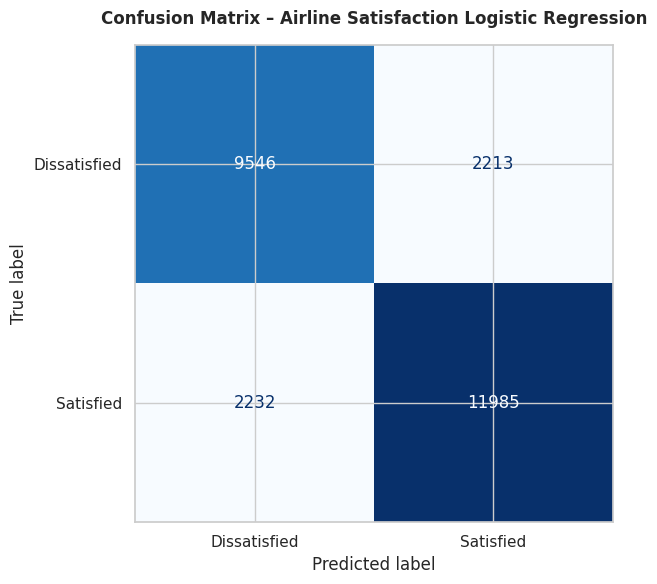

In [15]:
# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print('=' * 56)
print('          CONFUSION MATRIX BREAKDOWN')
print('=' * 56)
print(f'  True  Negatives (TN): {TN:>6,}  Correctly predicted DISSATISFIED')
print(f'  False Positives (FP): {FP:>6,}  Predicted satisfied → actually NOT')
print(f'  False Negatives (FN): {FN:>6,}  Missed satisfied passengers')
print(f'  True  Positives (TP): {TP:>6,}  Correctly predicted SATISFIED')
print('=' * 56)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Dissatisfied', 'Satisfied']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix – Airline Satisfaction Logistic Regression',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print('=' * 56)
print('         MODEL PERFORMANCE METRICS')
print('=' * 56)
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision : {precision:.4f}  ({precision*100:.2f}%)')
print(f'  Recall    : {recall:.4f}  ({recall*100:.2f}%)')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print('=' * 56)
print()
print('Full Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Dissatisfied', 'Satisfied']))

         MODEL PERFORMANCE METRICS
  Accuracy  : 0.8289  (82.89%)
  Precision : 0.8441  (84.41%)
  Recall    : 0.8430  (84.30%)
  F1-Score  : 0.8436
  ROC-AUC   : 0.9035

Full Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.81      0.81      0.81     11759
   Satisfied       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976



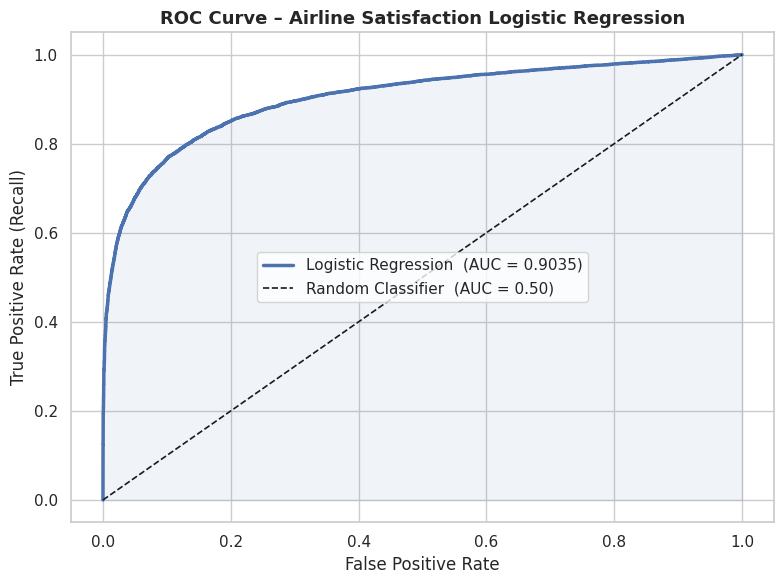


📌 AUC = 0.9035 → the model has strong discrimination ability.
   A perfect model scores 1.0; random guessing scores 0.5.


In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#4C72B0', linewidth=2.5,
         label=f'Logistic Regression  (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier  (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.08, color='#4C72B0')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve – Airline Satisfaction Logistic Regression', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 AUC = {roc_auc:.4f} → the model has strong discrimination ability.')
print('   A perfect model scores 1.0; random guessing scores 0.5.')

---
## 🔑 Step 10: Interpret Model Coefficients – Key Satisfaction Drivers

**How to read coefficients (after scaling):**
- **Positive coefficient** → feature *increases* probability of `satisfied`
- **Negative coefficient** → feature *decreases* probability (pushes toward `dissatisfied`)
- **Larger absolute value** = stronger influence
- Because features are standardised, coefficients are directly comparable in size

In [18]:
coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': lr_model.coef_[0]
})
coef_df['Abs_Coef']    = coef_df['Coefficient'].abs()
coef_df['Odds_Ratio']  = np.exp(coef_df['Coefficient'])
coef_df['Odds_Change%']= (coef_df['Odds_Ratio'] - 1) * 100
coef_df['Direction']   = coef_df['Coefficient'].apply(
    lambda x: '⬆️  Increases Satisfaction' if x > 0 else '⬇️  Decreases Satisfaction'
)
coef_df = coef_df.sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

print('Top 15 Features ranked by influence on satisfaction:')
print(coef_df[['Feature', 'Coefficient', 'Odds_Change%', 'Direction']].head(15).to_string(index=False))

Top 15 Features ranked by influence on satisfaction:
                          Feature  Coefficient  Odds_Change%                  Direction
           Inflight entertainment     0.972905    164.561933 ⬆️  Increases Satisfaction
                 CustomerType_enc    -0.725012    -51.568137 ⬇️  Decreases Satisfaction
                     Seat comfort     0.392582     48.079944 ⬆️  Increases Satisfaction
                 On-board service     0.387346     47.306678 ⬆️  Increases Satisfaction
                  Checkin service     0.355612     42.705429 ⬆️  Increases Satisfaction
                        Class_Eco    -0.354649    -29.858064 ⬇️  Decreases Satisfaction
                   TravelType_enc    -0.349626    -29.504846 ⬇️  Decreases Satisfaction
           Ease of Online booking     0.334382     39.707695 ⬆️  Increases Satisfaction
Departure/Arrival time convenient    -0.328774    -28.019452 ⬇️  Decreases Satisfaction
                 Leg room service     0.308623     36.154903 ⬆️  In

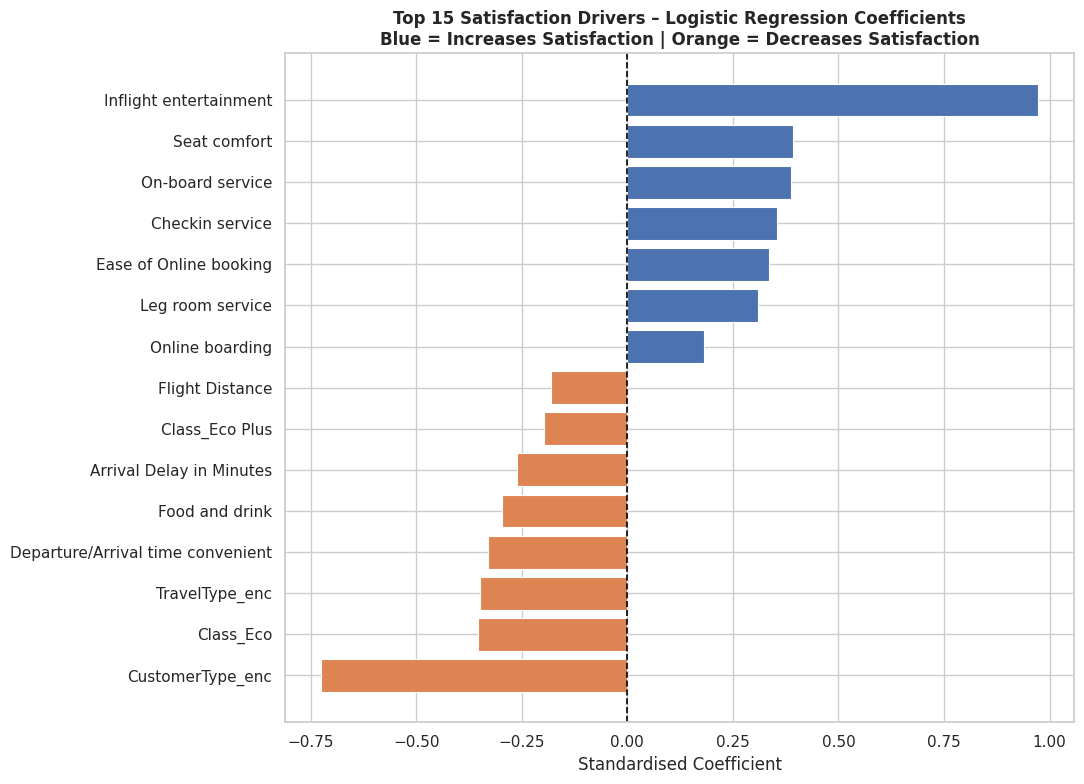


📌 INTERPRETATION GUIDE:
   • Inflight entertainment (coef ≈ +0.97) is the STRONGEST positive driver.
   • Customer Type_enc (coef ≈ −0.73): disloyal customers are less satisfied.
   • Class_Eco (coef ≈ −0.35): Economy class reduces satisfaction vs Business.
   • Seat comfort, On-board service, Checkin service all positively predict satisfaction.


In [19]:
top15 = coef_df.head(15).sort_values('Coefficient')
colors = ['#DD8452' if c < 0 else '#4C72B0' for c in top15['Coefficient']]

plt.figure(figsize=(11, 8))
bars = plt.barh(top15['Feature'], top15['Coefficient'], color=colors, edgecolor='white', linewidth=0.8)
plt.axvline(0, color='black', linewidth=1.2, linestyle='--')
plt.xlabel('Standardised Coefficient', fontsize=12)
plt.title('Top 15 Satisfaction Drivers – Logistic Regression Coefficients\n'
          'Blue = Increases Satisfaction | Orange = Decreases Satisfaction',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 INTERPRETATION GUIDE:')
print('   • Inflight entertainment (coef ≈ +0.97) is the STRONGEST positive driver.')
print('   • Customer Type_enc (coef ≈ −0.73): disloyal customers are less satisfied.')
print('   • Class_Eco (coef ≈ −0.35): Economy class reduces satisfaction vs Business.')
print('   • Seat comfort, On-board service, Checkin service all positively predict satisfaction.')

In [20]:
print('Odds Ratio Interpretation – Top 10 Features:')
print('(Odds Ratio > 1 = increases odds of satisfaction; < 1 = decreases)')
print()
print(coef_df[['Feature', 'Coefficient', 'Odds_Ratio', 'Odds_Change%']]
      .head(10)
      .to_string(index=False))
print()
print('💡 Example: Inflight entertainment has Odds_Change% ≈ +164.5%')
print('   → A 1-std increase in entertainment rating makes a passenger 2.6x more likely to be satisfied.')

Odds Ratio Interpretation – Top 10 Features:
(Odds Ratio > 1 = increases odds of satisfaction; < 1 = decreases)

                          Feature  Coefficient  Odds_Ratio  Odds_Change%
           Inflight entertainment     0.972905    2.645619    164.561933
                 CustomerType_enc    -0.725012    0.484319    -51.568137
                     Seat comfort     0.392582    1.480799     48.079944
                 On-board service     0.387346    1.473067     47.306678
                  Checkin service     0.355612    1.427054     42.705429
                        Class_Eco    -0.354649    0.701419    -29.858064
                   TravelType_enc    -0.349626    0.704952    -29.504846
           Ease of Online booking     0.334382    1.397077     39.707695
Departure/Arrival time convenient    -0.328774    0.719805    -28.019452
                 Leg room service     0.308623    1.361549     36.154903

💡 Example: Inflight entertainment has Odds_Change% ≈ +164.5%
   → A 1-std increase 

---
## 💼 Step 11: Business Recommendations

Based on our model (Accuracy: 82.9%, Precision: 84.4%, Recall: 84.3%, ROC-AUC: 0.9035), here are data-backed recommendations:

In [21]:
recommendations = """
╔══════════════════════════════════════════════════════════════════════════╗
║          ✈️  AIRLINE CUSTOMER SATISFACTION – BUSINESS RECOMMENDATIONS    ║
╚══════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 RECOMMENDATION 1: Invest in Inflight Entertainment
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  → Coefficient: +0.97 — STRONGEST predictor of satisfaction.
  → Odds Ratio: ~2.65 — passengers rating entertainment highly
    are 2.65x MORE likely to report satisfaction.
  → Action: Upgrade seatback screens on medium/long-haul routes;
    expand content library (local languages, sports, new releases).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 RECOMMENDATION 2: Implement a Loyalty Recovery Programme
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  → Coefficient: −0.73 for disloyal customers — they are
    significantly more likely to be dissatisfied.
  → Action: Create a welcome-back incentive for first 3 flights:
    priority boarding, bonus miles, or complimentary meal upgrade.
    Convert disloyal → loyal to lift their satisfaction probability.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 RECOMMENDATION 3: Enhance Seat Comfort & On-Board Service
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  → Both features carry coefficients ≈ +0.39, strong positive drivers.
  → Action: Retrofit Economy seats with additional lumbar support;
    train cabin crew on proactive service style.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 RECOMMENDATION 4: Improve Check-In & Online Booking Experience
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  → Checkin service (coef +0.36) and Ease of Online Booking (coef +0.33)
    are both positive drivers.
  → Action: Reduce check-in queue times with mobile/kiosk options;
    simplify the booking app UX and reduce steps to payment.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 RECOMMENDATION 5: Minimise Arrival Delays
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  → Arrival Delay (coef −0.26) negatively impacts satisfaction.
  → Action: Send proactive SMS/app delay notifications with voucher
    offers; prioritise on-time performance metrics at key hubs.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚠️  MODEL LIMITATIONS & NEXT STEPS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • Logistic Regression assumes LINEAR relationships — non-linear
    interactions between features are not captured.
  • Next model: Try Random Forest or XGBoost for higher accuracy.
  • Survey data may contain response bias.
  • Retrain the model quarterly as service standards evolve.
  • Deployment idea: Score passengers in real-time at check-in
    and offer service recovery to those predicted 'dissatisfied'.
"""

print(recommendations)


╔══════════════════════════════════════════════════════════════════════════╗
║          ✈️  AIRLINE CUSTOMER SATISFACTION – BUSINESS RECOMMENDATIONS    ║
╚══════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 RECOMMENDATION 1: Invest in Inflight Entertainment
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  → Coefficient: +0.97 — STRONGEST predictor of satisfaction.
  → Odds Ratio: ~2.65 — passengers rating entertainment highly
    are 2.65x MORE likely to report satisfaction.
  → Action: Upgrade seatback screens on medium/long-haul routes;
    expand content library (local languages, sports, new releases).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 RECOMMENDATION 2: Implement a Loyalty Recovery Programme
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  → Coefficient: −0.73 for disloyal customers — they are
    significantly more likely to be dissatisf

---
## ✅ Step 12: Final Performance Summary

In [22]:
summary = pd.DataFrame({
    'Metric'        : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score'         : [accuracy, precision, recall, f1, roc_auc],
    'Interpretation': [
        'Overall correct predictions across both classes',
        'Of all passengers predicted satisfied, 84.4% truly were (low false alarms)',
        'Of all truly satisfied passengers, 84.3% were correctly identified',
        'Balanced score between Precision and Recall',
        'Model separates satisfied from dissatisfied passengers with 90.4% discrimination'
    ]
})
summary['Score (%)'] = summary['Score'].mul(100).round(2).astype(str) + '%'

print('\n' + '=' * 80)
print('         ✈️  FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 80)
print(summary[['Metric', 'Score (%)', 'Interpretation']].to_string(index=False))
print('=' * 80)
print('\n🎉 Project complete!')
print('   Outputs saved: confusion_matrix.png | roc_curve.png | feature_coefficients.png')


         ✈️  FINAL MODEL PERFORMANCE SUMMARY
   Metric Score (%)                                                                   Interpretation
 Accuracy    82.89%                                  Overall correct predictions across both classes
Precision    84.41%       Of all passengers predicted satisfied, 84.4% truly were (low false alarms)
   Recall     84.3%               Of all truly satisfied passengers, 84.3% were correctly identified
 F1-Score    84.36%                                      Balanced score between Precision and Recall
  ROC-AUC    90.35% Model separates satisfied from dissatisfied passengers with 90.4% discrimination

🎉 Project complete!
   Outputs saved: confusion_matrix.png | roc_curve.png | feature_coefficients.png
